This notebook explores neural ordinary differential equations (neural ODEs) as a method for modeling time-dependent data. Instead of prescribing a fixed dynamical model, neural ODEs learn a continuous-time vector field directly from observations and generate predictions by numerically integrating the resulting differential equation.

The goal of this notebook is to examine how well neural ODEs can model observed dynamics across datasets of varying complexity. We focus on data-space modeling, where the system state is given directly by the measured variables and no prior knowledge of the true governing equations is assumed.

The approach is evaluated on three datasets:

- A synthetic sine wave as a simple baseline
- The lynx-hare population dataset, exhibiting coupled nonlinear dynamics
- COVID-19 daily infection data, representing noisy real-world observations

For each dataset, the same neural ODE architecture and training procedure are used. Model performance is assessed by integrating the learned dynamics forward in time and comparing the resulting trajectories to the observed data.

## Neural ODE architecture

We model the dynamics of a time-dependent system using a neural ordinary differential equation (neural ODE):

$$
\frac{dy}{dt} = f_\theta(t, y),
$$

where $y(t) \in \mathbb{R}^d$ is the observed system state and $f_\theta$ is a neural network with parameters $\theta$. Given an initial condition $y(t_0)$, predictions are produced by numerically integrating the ODE forward in time.

### Vector field parameterization

The vector field $f_\theta(t, y)$ is implemented as a multilayer perceptron (MLP). We concatenate the current state $y$ with time $t$ and feed $[y, t]$ into the network, which outputs an estimate of the derivative $\dot{y}$.

Including $t$ makes the dynamics explicitly time-dependent (non-autonomous). An alternative is to omit time and learn an autonomous system $f_\theta(y)$, which can be preferable when the underlying dynamics are time-invariant.

The MLP uses tanh activations and a modest depth and width to balance expressiveness and training stability. Other common choices include ReLU or SiLU activations, deeper networks, or architectures that encode structure (for example, constraints or invariances).

## Learnable initial condition

In addition to learning the vector field $f_\theta(t, y)$, we treat the initial state $y_0$ as a learnable parameter. This is useful when the first observation is noisy or when the true latent initial condition is not exactly equal to the first measured data point.

Concretely, we store $y_0$ inside the model and optimize it jointly with the neural network parameters using the same loss and optimizer.

### Numerical integration

Predictions are obtained by solving the ODE with a numerical integrator. During training and evaluation we use a simple fixed-step Euler solver for speed and stability.

Different solver families, step sizes, and error tolerances can change both training stability and final accuracy. In this notebook we separate training and evaluation solvers to make this trade-off explicit.

Overall, this setup is a minimal neural ODE baseline that highlights the main modeling decisions while leaving room for more advanced extensions.

In [1]:
import equinox as eqx
import jax.numpy as jnp
import jax.nn as jnn
import diffrax
import jax.random as jr
import optax
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class Func(eqx.Module):
    mlp: eqx.nn.MLP
    out_scale: jnp.ndarray
    
    def __init__(self, in_dim, out_dim, width, depth, *, key):
        self.mlp = eqx.nn.MLP(
            in_dim,
            out_dim,
            width,
            depth,
            activation=jnn.tanh,
            final_activation=jnn.tanh,
            key=key,
        )
        self.out_scale = jnp.ones(out_dim)
    
    def __call__(self, t, y, args):
        inp = jnp.concatenate([y, jnp.atleast_1d(t)])
        return self.out_scale * self.mlp(inp)

class NeuralODE(eqx.Module):
    func: Func
    y0: jnp.ndarray
    
    def __init__(self, func, y0_init):
        self.func = func
        self.y0 = jnp.array(y0_init)
    
    def __call__(self, ts, substeps: int = 4):
        term = diffrax.ODETerm(self.func)
        solver = diffrax.Euler()
        dt_data = ts[1] - ts[0]
        dt_solver = dt_data / substeps
        saveat = diffrax.SaveAt(ts=ts)
        
        sol = diffrax.diffeqsolve(
            term,
            solver,
            t0=ts[0],
            t1=ts[-1],
            dt0=dt_solver,
            y0=self.y0,
            saveat=saveat,
            stepsize_controller=diffrax.ConstantStepSize(),
        )
        return sol.ys

## Training setup

We train the neural ODE by minimizing mean squared error between the predicted trajectory and the observed data at the same time points. For each optimization step, we solve the ODE on the full time grid `ts`, producing predictions `y_pred`, and compute

$$
\mathcal{L} = \frac{1}{N}\sum_{i=1}^N \lVert y_{\text{pred}}(t_i) - y(t_i) \rVert^2.
$$

Gradients are computed through the ODE solve using Equinox filtering utilities. We use `eqx.filter_value_and_grad` so gradients are taken only with respect to trainable array parameters, and we JIT-compile the per-step update with `eqx.filter_jit` for speed.

Optimization is performed with Adam. This baseline uses full-batch training (the entire trajectory per step) rather than minibatches, which is simple and works well for short time series, but can be expensive for longer sequences.

In [4]:
@eqx.filter_value_and_grad
def grad_loss(model, ts, ys):
    y_pred = model(ts, substeps=4)  # Training uses 4 substeps with Euler (hardcoded in model)
    return jnp.mean((y_pred - ys) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, ts, ys, optimizer):
    loss, grads = grad_loss(model, ts, ys)
    updates, opt_state = optimizer.update(grads, opt_state)
    model = eqx.apply_updates(model, updates)
    return loss, model, opt_state

## Experiment 1 - Sine wave

We start with a simple 1D sine wave dataset. This is a sanity check that the neural ODE implementation and training loop can learn a smooth trajectory in a controlled setting.

We train the model on the sine observations, then integrate the learned dynamics and compare the predicted trajectory against the data.

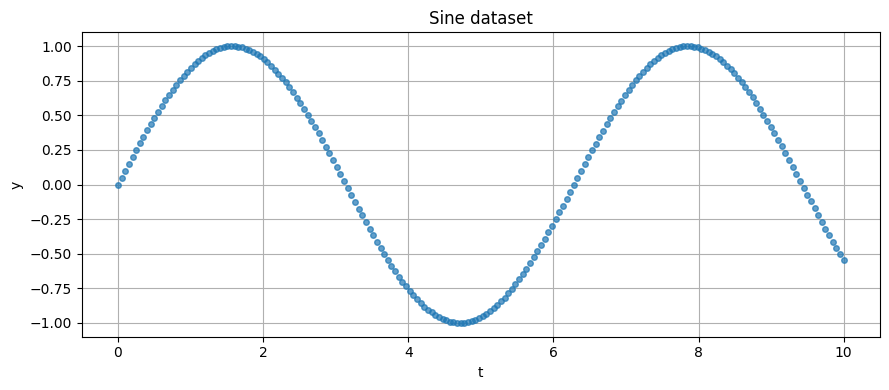

In [9]:
def get_sine_data(num_points: int = 200, t_max: float = 10.0):
    ts_raw = jnp.linspace(0, t_max, num_points)
    ys = jnp.sin(ts_raw).reshape(-1, 1)
    
    # Standardize time (center and scale)
    ts = (ts_raw - ts_raw.mean()) / ts_raw.std()
    
    return ts, ys, None, ts_raw  # Return original time for plotting

ts, ys, transform, ts_original = get_sine_data()

plt.figure(figsize=(9, 4))
plt.plot(np.array(ts_original), np.array(ys[:, 0]), "o", markersize=4, alpha=0.7)
plt.title("Sine dataset")
plt.xlabel("t")
plt.ylabel("y")
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# --- Initialize model ---
SEED = 42
WIDTH = 32
DEPTH = 2

key = jr.PRNGKey(SEED)

func = Func(
    in_dim=ys.shape[-1] + 1,
    out_dim=ys.shape[-1],
    width=WIDTH,
    depth=DEPTH,
    key=key,
)

model = NeuralODE(func, ys[0])  # y0 is a parameter inside the model

In [11]:
# train
NUM_STEPS = 5_000
PRINT_EVERY = 1_000
LEARNING_RATE = 0.005

optimizer = optax.adam(LEARNING_RATE)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

loss_history = []
for step in range(NUM_STEPS):
    loss, model, opt_state = train_step(model, opt_state, ts, ys, optimizer)
    loss_history.append(float(loss))
    if step % PRINT_EVERY == 0:
        print(f"Step {step:5d} | loss = {loss:.6f} | y0 = {np.array(model.y0)} | out_scale = {np.array(model.func.out_scale)}")

Step     0 | loss = 0.669892 | y0 = [0.00499997] | out_scale = [0.995]
Step  1000 | loss = 0.000775 | y0 = [0.06486437] | out_scale = [2.6147892]
Step  2000 | loss = 0.000095 | y0 = [0.03001547] | out_scale = [2.857484]
Step  3000 | loss = 0.003128 | y0 = [0.01789063] | out_scale = [2.94581]
Step  4000 | loss = 0.000022 | y0 = [0.01314948] | out_scale = [3.0021725]


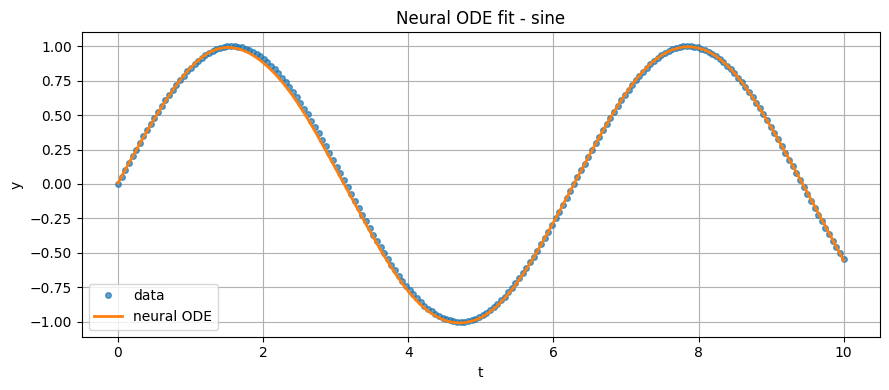

In [12]:
# --- Evaluate + plot trajectory ---
t_fine = jnp.linspace(ts[0], ts[-1], 400)
y_fine = model(t_fine)

# Convert normalized time back to original
ts_fine_original = np.array(t_fine) * ts_original.std() + ts_original.mean()

plt.figure(figsize=(9, 4))
plt.plot(np.array(ts_original), np.array(ys[:, 0]), "o", label="data", markersize=4, alpha=0.7)
plt.plot(ts_fine_original, np.array(y_fine[:, 0]), "-", label="neural ODE", linewidth=2)
plt.title("Neural ODE fit - sine")
plt.xlabel("t")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 2 - Lynx-Hare populations

Next, we apply the same neural ODE model to the lynx-hare dataset. This is a 2D time series (hares and lynx) with coupled dynamics.

We standardize each population dimension (zero mean, unit variance) and also normalize time (center and scale). The model is trained in this normalized space for stability. For visualization, we invert the normalization to plot predictions in the original units.

lynx-hare data:
ts shape: (30,)
ys shape: (30, 2)
ys min: [-1.164889  -1.1040605]
ys max: [2.6919296 2.418097 ]
ys mean: [1.9868216e-08 4.0729841e-08]
ys std: [0.99999994 1.        ]


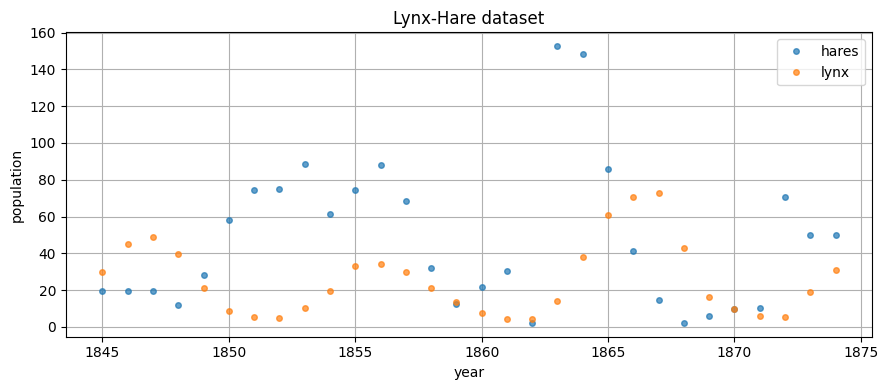

In [13]:
# --- Load lynx-hare dataset + plot (normalized) ---
LYNX_HARE_PATH = "/Users/gabriel.brown/Documents/nde/week3_neural_ode/data/raw/LH_data.npy"

class DataTransform:
    def __init__(self, mean: np.ndarray, std: np.ndarray):
        self.mean = mean
        self.std = std
    
    def forward(self, y: np.ndarray) -> np.ndarray:
        return (y - self.mean) / self.std
    
    def inverse(self, y: np.ndarray) -> np.ndarray:
        return y * self.std + self.mean

def load_lynx_hare_data(
    path: str = LYNX_HARE_PATH,
    normalize: bool = True,
    return_transform: bool = True
):
    raw = np.load(path)
    years = raw[:, 0]
    hares = raw[:, 1]
    lynx = raw[:, 2]
    
    ys_np = np.stack([hares, lynx], axis=1)  # Shape (N, 2)
    mean, std = ys_np.mean(axis=0), ys_np.std(axis=0)
    transform = DataTransform(mean, std)
    
    if normalize:
        ys_np = transform.forward(ys_np)
    
    # Standardize time (center and scale)
    ts_np = (years - years.mean()) / years.std()
    
    ts = jnp.array(ts_np, dtype=jnp.float32)
    ys = jnp.array(ys_np, dtype=jnp.float32)
    
    if return_transform:
        return ts, ys, transform, years  # Return original years for plotting
    return ts, ys

ts, ys, transform, years_original = load_lynx_hare_data()
print("lynx-hare data:")
print("ts shape:", ts.shape)
print("ys shape:", ys.shape)
print("ys min:", np.array(ys).min(axis=0))
print("ys max:", np.array(ys).max(axis=0))
print("ys mean:", np.array(ys).mean(axis=0))
print("ys std:", np.array(ys).std(axis=0))

# --- Plot in original units ---
ys_real = transform.inverse(np.array(ys))

plt.figure(figsize=(9, 4))
plt.plot(years_original, ys_real[:, 0], "o", label="hares", markersize=4, alpha=0.7)
plt.plot(years_original, ys_real[:, 1], "o", label="lynx", markersize=4, alpha=0.7)
plt.title("Lynx-Hare dataset")
plt.xlabel("year")
plt.ylabel("population")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
#initialize model
SEED = 42
WIDTH = 32
DEPTH = 2

key = jr.PRNGKey(SEED)

func = Func(
    in_dim=ys.shape[-1] + 1,
    out_dim=ys.shape[-1],
    width=WIDTH,
    depth=DEPTH,
    key=key,
)
model = NeuralODE(func, ys[0])

In [21]:
# --- Training config  ---
LEARNING_RATE = 0.005
NUM_STEPS = 20_000

# Add simple exponential decay to stabilize late training
schedule = optax.exponential_decay(
    init_value=LEARNING_RATE,
    transition_steps=NUM_STEPS // 4,  # Decay over last 75% of training
    decay_rate=0.4,
    staircase=False
)

# Simple optimizer with decay
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(schedule),
)
opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

Step     0 | loss = 1.351677 | y0 = [-0.7138954   0.23463164] | out_scale = [0.99500006 0.99500006]
Step  1000 | loss = 0.513225 | y0 = [-0.8451944  1.0226055] | out_scale = [1.913932  2.8201513]
Step  2000 | loss = 0.318499 | y0 = [-0.70302594  1.6350832 ] | out_scale = [3.4564862 4.37397  ]
Step  3000 | loss = 0.256142 | y0 = [-0.6969887  1.7089858] | out_scale = [4.8044033 5.0954566]
Step  4000 | loss = 0.156068 | y0 = [-0.59572685  0.7093582 ] | out_scale = [5.8640122 6.5470366]
Step  5000 | loss = 0.126336 | y0 = [-0.65342844  0.48171175] | out_scale = [6.8763986 7.2515287]
Step  6000 | loss = 0.110429 | y0 = [-0.67746925  0.3849337 ] | out_scale = [7.848016  7.5759854]
Step  7000 | loss = 0.097141 | y0 = [-0.68637216  0.34800565] | out_scale = [8.728364  7.7548633]
Step  8000 | loss = 0.086056 | y0 = [-0.6824998  0.3276297] | out_scale = [9.470926 8.111794]
Step  9000 | loss = 0.079500 | y0 = [-0.67756253  0.3159346 ] | out_scale = [10.16689   8.325534]
Step 10000 | loss = 0.0847

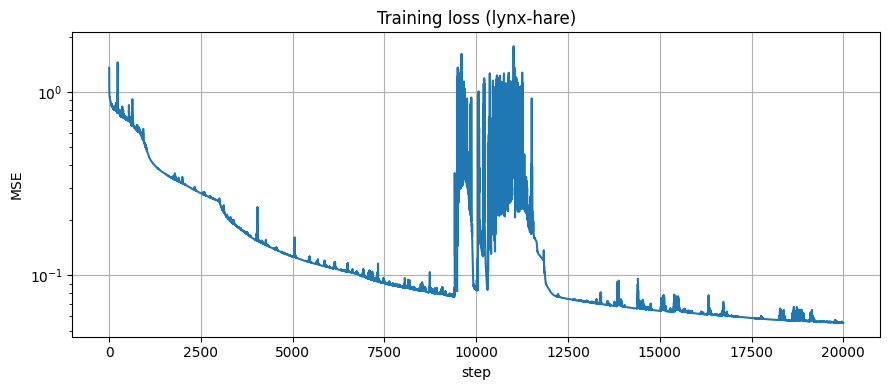

In [22]:
# --- Train ---
PRINT_EVERY = 1_000

loss_history = []
for step in range(NUM_STEPS):
    loss, model, opt_state = train_step(model, opt_state, ts, ys, optimizer)
    loss_history.append(float(loss))
    if step % PRINT_EVERY == 0:
        print(f"Step {step:5d} | loss = {loss:.6f} | y0 = {np.array(model.y0)} | out_scale = {np.array(model.func.out_scale)}")

plt.figure(figsize=(9, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training loss (lynx-hare)")
plt.xlabel("step")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

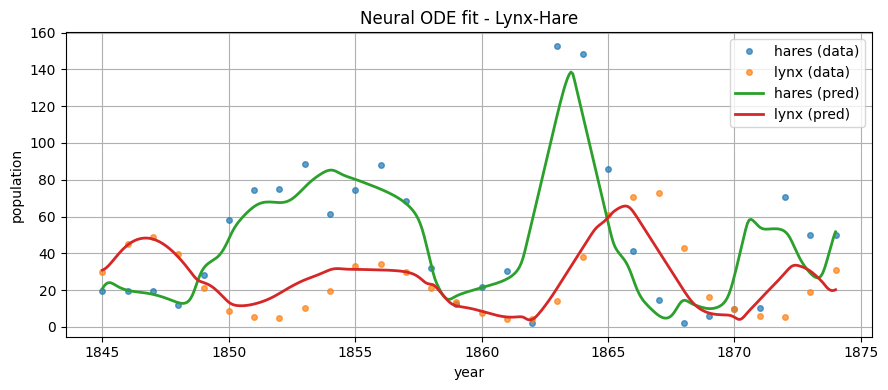

In [23]:
# --- Evaluate + plot in original units ---
t_fine = jnp.linspace(ts[0], ts[-1], 400)
y_fine = model(t_fine, substeps=1)
y_fine_real = transform.inverse(np.array(y_fine))
ys_real = transform.inverse(np.array(ys))

# Convert normalized time back to original years
years_fine = np.array(t_fine) * years_original.std() + years_original.mean()

plt.figure(figsize=(9, 4))
plt.plot(years_original, ys_real[:, 0], "o", label="hares (data)", markersize=4, alpha=0.7)
plt.plot(years_original, ys_real[:, 1], "o", label="lynx (data)", markersize=4, alpha=0.7)
plt.plot(years_fine, y_fine_real[:, 0], "-", label="hares (pred)", linewidth=2)
plt.plot(years_fine, y_fine_real[:, 1], "-", label="lynx (pred)", linewidth=2)
plt.title("Neural ODE fit - Lynx-Hare")
plt.xlabel("year")
plt.ylabel("population")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Experiment 3 - COVID-19 daily infection data

In the final experiment, we apply the neural ODE model to real-world epidemiological data: daily new COVID-19 infection counts. Unlike the previous datasets, this time series is noisy, non-periodic, and exhibits sharp changes in scale, making it a more challenging modeling task.

To improve numerical stability and reduce the dynamic range of the data, we apply a log(1 + x) transform to the infection counts, followed by standardization. Time is also centered and scaled. The neural ODE is trained in this transformed space, and predictions are later mapped back to the original scale for interpretation.

This experiment tests the ability of neural ODEs to model irregular, non-smooth dynamics driven by real-world processes, and highlights the limitations of continuous-time models when applied to noisy observational data.

covid:
ts shape: (100,)
ys shape: (100, 1)
ys min: -3.183266
ys max: 1.3284991
ys mean: -4.917383e-07
ys std: 0.99999994


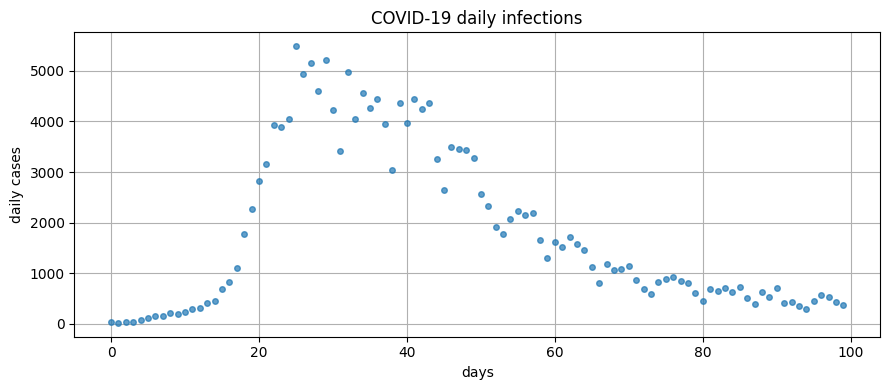

In [24]:
# =========================
# Load COVID-19 dataset
# =========================
COVID_PATH = "/Users/gabriel.brown/Documents/nde/week3_neural_ode/data/raw/covid_data.npy"

class DataTransform:
    def __init__(self, mean: np.ndarray, std: np.ndarray):
        self.mean = mean
        self.std = std
    
    def forward(self, y: np.ndarray) -> np.ndarray:
        return (y - self.mean) / self.std
    
    def inverse(self, y: np.ndarray) -> np.ndarray:
        # Undo standardization
        y = y * self.std + self.mean
        # Undo log1p transform
        y = np.expm1(y)  # expm1(x) = exp(x) - 1, inverse of log1p
        return y

def load_covid_data(
    path: str = COVID_PATH,
    normalize: bool = True,
    return_transform: bool = True
):
    raw = np.load(path)
    days = raw[:, 0]
    cases = raw[:, 1]
    
    # Log transform for exponential growth
    ys_np = np.log1p(cases).reshape(-1, 1)  # log(1 + cases) to handle zeros
    
    # Simple standardization after log
    mean, std = ys_np.mean(axis=0), ys_np.std(axis=0)
    transform = DataTransform(mean, std)
    
    if normalize:
        ys_np = transform.forward(ys_np)
    
    # Standardize time (center and scale) but keep original for plotting
    ts_mean = days.mean()
    ts_std = days.std()
    ts_np = (days - ts_mean) / ts_std
    
    ts = jnp.array(ts_np, dtype=jnp.float32)
    ys = jnp.array(ys_np, dtype=jnp.float32)
    
    if return_transform:
        return ts, ys, transform, days  # Return original days for plotting
    return ts, ys

# --- Load data ---
ts, ys, transform, days_original = load_covid_data()
print("covid:")
print("ts shape:", ts.shape)
print("ys shape:", ys.shape)
print("ys min:", np.array(ys).min())
print("ys max:", np.array(ys).max())
print("ys mean:", np.array(ys).mean())
print("ys std:", np.array(ys).std())

# --- Plot in original units ---
ys_real = transform.inverse(np.array(ys))

plt.figure(figsize=(9, 4))
plt.plot(days_original, ys_real[:, 0], "o", markersize=4, alpha=0.7)
plt.title("COVID-19 daily infections")
plt.xlabel("days")
plt.ylabel("daily cases")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
#initialize model
WIDTH = 32
DEPTH = 2
SEED = 42

key = jr.PRNGKey(SEED)

func = Func(
    in_dim=ys.shape[-1]+1,
    out_dim=ys.shape[-1],
    width=WIDTH,
    depth=DEPTH,
    key=key,
)
model = NeuralODE(func, ys[0])  # y0 is learnable

In [27]:
#training parameters
LEARNING_RATE = 0.005
NUM_STEPS = 10_000

# Add simple exponential decay to stabilize late training
schedule = optax.exponential_decay(
    init_value=LEARNING_RATE,
    transition_steps=NUM_STEPS // 4,  # Decay over last 75% of training
    decay_rate=0.5,
    staircase=False
)

# Simple optimizer with decay
optimizer = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adam(schedule),
)

opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

Step     0 | loss = 9.823399 | y0 = [-2.7518644] | out_scale = [0.99500006]
Step  1000 | loss = 0.111886 | y0 = [-1.8854656] | out_scale = [2.9481785]
Step  2000 | loss = 0.049856 | y0 = [-2.3543568] | out_scale = [3.8543034]
Step  3000 | loss = 0.029135 | y0 = [-2.6417155] | out_scale = [4.4642344]
Step  4000 | loss = 0.023229 | y0 = [-2.8029513] | out_scale = [4.829246]
Step  5000 | loss = 0.021065 | y0 = [-2.8881023] | out_scale = [5.046309]
Step  6000 | loss = 0.020217 | y0 = [-2.9365566] | out_scale = [5.169949]
Step  7000 | loss = 0.019984 | y0 = [-2.9585023] | out_scale = [5.227001]
Step  8000 | loss = 0.019886 | y0 = [-2.966829] | out_scale = [5.2489905]
Step  9000 | loss = 0.019821 | y0 = [-2.9693623] | out_scale = [5.255731]


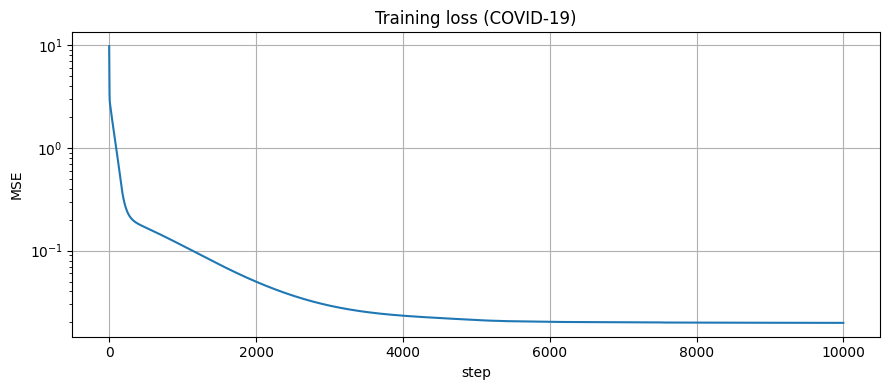

In [28]:
# --- Train ---
PRINT_EVERY = 1_000

loss_history = []
for step in range(NUM_STEPS):
    loss, model, opt_state = train_step(model, opt_state, ts, ys, optimizer)
    loss_history.append(float(loss))
    if step % PRINT_EVERY == 0:
        print(f"Step {step:5d} | loss = {loss:.6f} | y0 = {np.array(model.y0)} | out_scale = {np.array(model.func.out_scale)}")

plt.figure(figsize=(9, 4))
plt.plot(loss_history)
plt.yscale("log")
plt.title("Training loss (COVID-19)")
plt.xlabel("step")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

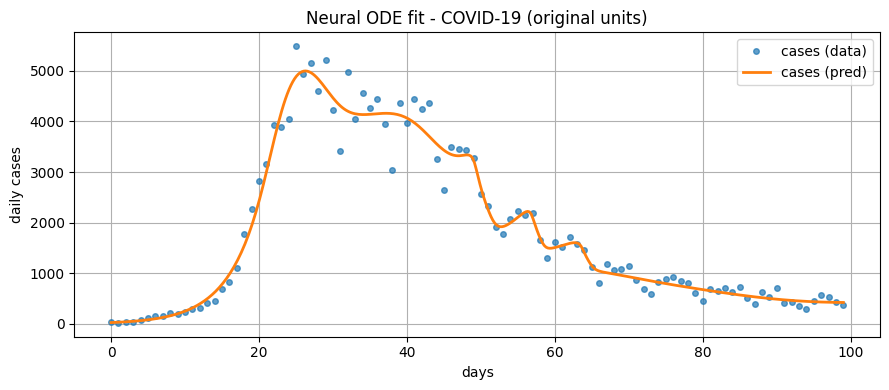

In [284]:
# --- Evaluate + plot in original units ---
t_fine = jnp.linspace(ts[0], ts[-1], 400)
y_fine = model(t_fine, substeps=1)
y_fine_real = transform.inverse(np.array(y_fine))
ys_real = transform.inverse(np.array(ys))

# Convert normalized time back to original days
days_fine = np.array(t_fine) * days_original.std() + days_original.mean()

plt.figure(figsize=(9, 4))
plt.plot(days_original, ys_real[:, 0], "o", label="cases (data)", markersize=4, alpha=0.7)
plt.plot(days_fine, y_fine_real[:, 0], "-", label="cases (pred)", linewidth=2)
plt.title("Neural ODE fit - COVID-19 (original units)")
plt.xlabel("days")
plt.ylabel("daily cases")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Discussion

## Performance Across Datasets

### Sine Wave Dataset
The Neural ODE achieved near-perfect performance on the sine wave dataset, which aligns with theoretical expectations. A sine wave is fundamentally described by the differential equation dy/dt = cos(t), making it an ideal candidate for ODE-based modeling. The model successfully learned both the amplitude and frequency of the oscillation with minimal error, demonstrating the effectiveness of Neural ODEs for dynamics that can be cleanly expressed as differential equations.

### Lynx-Hare Population Dataset
The lynx-hare dataset proved most challenging for the Neural ODE, yielding the poorest fit of the three datasets. Several factors contribute to this difficulty:

1. **Data Sparsity**: The dataset contains relatively few temporal observations, making it difficult to reliably infer the underlying dynamics
2. **Smoothness Prior**: Neural ODEs have an implicit bias toward smooth trajectories (a consequence of the continuous dynamics assumption), which helps prevent overfitting but can make it difficult to fit data points precisely when they exhibit irregular patterns

The model prioritizes learning a smooth, generalizable trajectory over fitting every data point exactly—a desirable property for generalization, but one that limits performance when ground truth dynamics are noisy or when data is sparse.

### COVID-19 Dataset
The Neural ODE performed quite well on the COVID-19 infection data, successfully capturing both low-frequency trends (overall epidemic curve) and high-frequency dynamics (weekly fluctuations in case counts).

## Key Insights for Training Neural ODEs

### Hyperparameter Tuning
Successful training of Neural ODEs requires careful attention to several hyperparameters:

- **Learning Rate**: We found that a learning rate of 0.005 with exponential decay provided quick training across all datasets. We see late-stage instabilities in the training which I somewhat mitigated through a decay schedule applied to the learning rate.
- **Solver Configuration**: Using a simple Euler solver with 4 substeps during training provided fast, stable gradients, while evaluation could use more sophisticated solvers for accuracy

### The Importance of Output Scaling
A critical architectural insight is the role of the final activation function and output scaling. Using tanh as a final activation bounds the network's output to the range [-1, 1], which directly limits the magnitude of derivatives the model can represent. Since the vector field dy/dt = out_scale × tanh(MLP(y, t)), without scaling the maximum possible derivative would be ±1, severely constraining the model's ability to learn fast dynamics.

**Solution**: We introduced a learnable `out_scale` parameter that multiplies the network output, allowing the model to learn appropriate derivative magnitudes during training. This simple modification was essential for achieving good performance, particularly on the COVID dataset where rapid exponential growth required large derivative values that would be impossible to represent with the base tanh output alone.

### Data Normalization Strategies
Proper data preprocessing was essential:

- **Time Normalization**: Standardizing time (zero mean, unit variance) helped stabilize training across all datasets
- **State Normalization**: For population data, standardization after log-transform worked well. For sine waves, no transform was needed
- **Autonomous vs. Time-Dependent**: Including time as an input to the vector field (non-autonomous ODEs) generally improved performance, as it allowed the model to learn time-varying dynamics

## Limitations and Future Directions

While Neural ODEs showed promise, several limitations emerged:

1. **Data Requirements**: Performance degrades significantly with sparse data (as seen with lynx-hare)
2. **Deterministic Assumption**: Real-world systems often have stochastic components that deterministic ODEs cannot capture
3. **Computational Cost**: Each forward pass requires solving an ODE, making training slower than standard neural networks

Future work could explore:
- **Neural SDEs** (Stochastic Differential Equations) to capture noise and uncertainty
- **Hybrid models** that combine Neural ODEs with data-driven priors for sparse data regimes
- **Uncertainty quantification** to distinguish between epistemic uncertainty (lack of data) and aleatoric uncertainty (inherent stochasticity)

## Conclusion

Neural ODEs provide a powerful framework for learning continuous-time dynamics from data, particularly when the underlying system can be well-approximated by differential equations. Success depends critically on appropriate preprocessing, careful hyperparameter tuning, and architectural choices that allow sufficient expressivity (such as learnable output scaling). While challenges remain for noisy or sparse datasets, the strong performance on well-sampled data (sine, COVID) demonstrates the promise of this approach for scientific modeling and forecasting.